Detected minimum quasienergy gap in 0 <= A/omega <= 2: A/omega = 1.202405, gap = 9.273205e-03


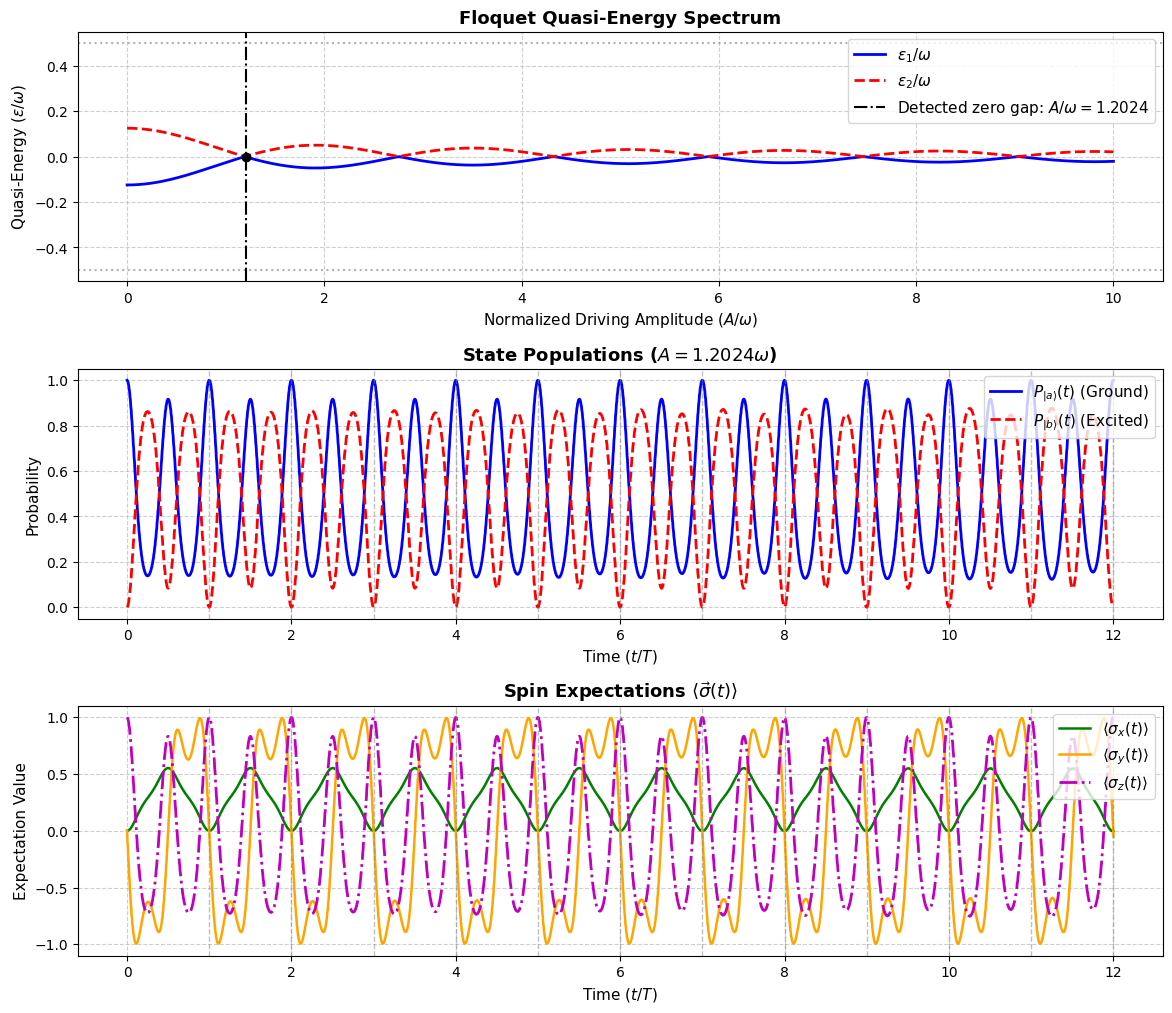

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# =====================================================================
# 1. Pauli Matrices and System Parameters
# =====================================================================
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
identity = np.eye(2, dtype=complex)

# System Parameters
Delta =1         # Energy level spacing
omega = 4.0       # Driving frequency
T = 2 * np.pi / omega

def H(t, A):
    """Time-dependent Hamiltonian"""
    return 0.5 * Delta * sigma_z + A * np.cos(omega * t) * sigma_x

def compute_floquet_quasienergies(A, n_steps=200):
    """Compute quasi-energy spectrum from the single-period evolution operator."""
    dt = T / n_steps
    U = np.eye(2, dtype=complex)
    for step in range(n_steps):
        t = (step + 0.5) * dt
        U = expm(-1j * H(t, A) * dt) @ U

    eigenvalues = np.linalg.eigvals(U)
    quasi_energies = -np.angle(eigenvalues) / T
    quasi_energies = (quasi_energies + omega / 2) % omega - omega / 2
    return np.sort(quasi_energies)

# =====================================================================
# 2. Compute quasi-energy spectrum and detect the zero-gap ratio
# =====================================================================
A_values = np.linspace(0, 10 * omega, 500)
quasi_energies = np.array([
    compute_floquet_quasienergies(A) for A in A_values
])

quasienergy_gap = np.abs(quasi_energies[:, 1] - quasi_energies[:, 0])
search_mask = (A_values / omega >= 0.0) & (A_values / omega <= 2.0)
search_indices = np.flatnonzero(search_mask)
zero_gap_index = search_indices[np.argmin(quasienergy_gap[search_indices])]
ratio = A_values[zero_gap_index] / omega
minimum_gap = quasienergy_gap[zero_gap_index]
print(
    f'Detected minimum quasienergy gap in 0 <= A/omega <= 2: '
    f'A/omega = {ratio:.6f}, gap = {minimum_gap:.6e}'
)

# =====================================================================
# 3. Algebraic Method for Time Evolution
# =====================================================================
A_sim = ratio * omega
psi0 = np.array([1.0, 0.0], dtype=complex)

N_tau = 300
dt = T / N_tau
tau_grid = np.linspace(0, T, N_tau, endpoint=False)
U_tau = np.zeros((N_tau, 2, 2), dtype=complex)
U_curr = np.eye(2, dtype=complex)

for step, tau in enumerate(tau_grid):
    U_tau[step] = U_curr
    H_mid = H(tau + 0.5 * dt, A_sim)
    U_curr = expm(-1j * H_mid * dt) @ U_curr

U_T = U_curr

eigenvals, eigenvecs = np.linalg.eig(U_T)
u0_alpha = [eigenvecs[:, 0], eigenvecs[:, 1]]
eps_alpha = -np.angle(eigenvals) / T
c_alpha = [np.vdot(u0_alpha[0], psi0), np.vdot(u0_alpha[1], psi0)]

u_modes = np.zeros((2, N_tau, 2), dtype=complex)
for alpha in range(2):
    for i, tau in enumerate(tau_grid):
        u_modes[alpha, i] = (
            np.exp(1j * eps_alpha[alpha] * tau)
            * (U_tau[i] @ u0_alpha[alpha])
        )

t_eval = np.linspace(0, 12 * T, 2400)
tau_indices = (
    np.round((t_eval % T) / T * N_tau).astype(int)
) % N_tau

# Algebraic synthesis formula:
# |psi(t)> = sum_alpha c_alpha exp(-i eps_alpha t) |u_alpha(tau)>
psi_t = (
    c_alpha[0] * np.exp(-1j * eps_alpha[0] * t_eval)[:, None]
    * u_modes[0, tau_indices]
    + c_alpha[1] * np.exp(-1j * eps_alpha[1] * t_eval)[:, None]
    * u_modes[1, tau_indices]
).T

# =====================================================================
# 4. Compute Algebraic Observables
# =====================================================================
P0 = np.abs(psi_t[0])**2
P1 = np.abs(psi_t[1])**2
sx = np.real(np.sum(np.conj(psi_t) * (sigma_x @ psi_t), axis=0))
sy = np.real(np.sum(np.conj(psi_t) * (sigma_y @ psi_t), axis=0))
sz = np.real(np.sum(np.conj(psi_t) * (sigma_z @ psi_t), axis=0))

# =====================================================================
# 5. Plotting and Visualization
# =====================================================================
fig = plt.figure(figsize=(14, 12))
plt.subplots_adjust(hspace=0.35)

ax1 = plt.subplot(3, 1, 1)
ax1.plot(A_values / omega, quasi_energies[:, 0] / omega,
         'b-', lw=2, label=r'$\epsilon_1 / \omega$') 
ax1.plot(A_values / omega, quasi_energies[:, 1] / omega,
         'r--', lw=2, label=r'$\epsilon_2 / \omega$')
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.6)
ax1.axhline(-0.5, color='gray', linestyle=':', alpha=0.6)
ax1.axvline(
    ratio, color='black', linestyle='-.', linewidth=1.5,
    label=rf'Detected zero gap: $A/\omega={ratio:.4f}$',
)
ax1.scatter(
    ratio, quasi_energies[zero_gap_index, 0] / omega,
    color='black', zorder=5,
)
ax1.set_title(r'Floquet Quasi-Energy Spectrum', fontsize=13, fontweight='bold')
ax1.set_xlabel(r'Normalized Driving Amplitude ($A / \omega$)', fontsize=11)
ax1.set_ylabel(r'Quasi-Energy ($\epsilon / \omega$)', fontsize=11)
ax1.set_ylim([-0.55, 0.55])
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right', fontsize=11)

ax2 = plt.subplot(3, 1, 2)
ax2.plot(t_eval / T, P0, 'b-', label=r'$P_{|a\rangle}(t)$ (Ground)', lw=2)
ax2.plot(t_eval / T, P1, 'r--', label=r'$P_{|b\rangle}(t)$ (Excited)', lw=2)
for i in range(1, 13):
    ax2.axvline(i, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_title(
    rf'State Populations ($A = {ratio:.4f}\omega$)',
    fontsize=13, fontweight='bold',
)
ax2.set_xlabel(r'Time ($t / T$)', fontsize=11)
ax2.set_ylabel('Probability', fontsize=11)
ax2.set_ylim([-0.05, 1.05])
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11)

ax3 = plt.subplot(3, 1, 3)
ax3.plot(t_eval / T, sx, 'g-', label=r'$\langle \sigma_x(t) \rangle$', lw=1.8)
ax3.plot(t_eval / T, sy, 'orange', label=r'$\langle \sigma_y(t) \rangle$', lw=1.8)
ax3.plot(t_eval / T, sz, 'm-.', label=r'$\langle \sigma_z(t) \rangle$', lw=2)
for i in range(1, 13):
    ax3.axvline(i, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax3.set_title(
    r'Spin Expectations $\langle \vec{\sigma}(t) \rangle$',
    fontsize=13, fontweight='bold',
)
ax3.set_xlabel(r'Time ($t / T$)', fontsize=11)
ax3.set_ylabel('Expectation Value', fontsize=11)
ax3.set_ylim([-1.1, 1.1])
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(loc='upper right', fontsize=11)

plt.show()

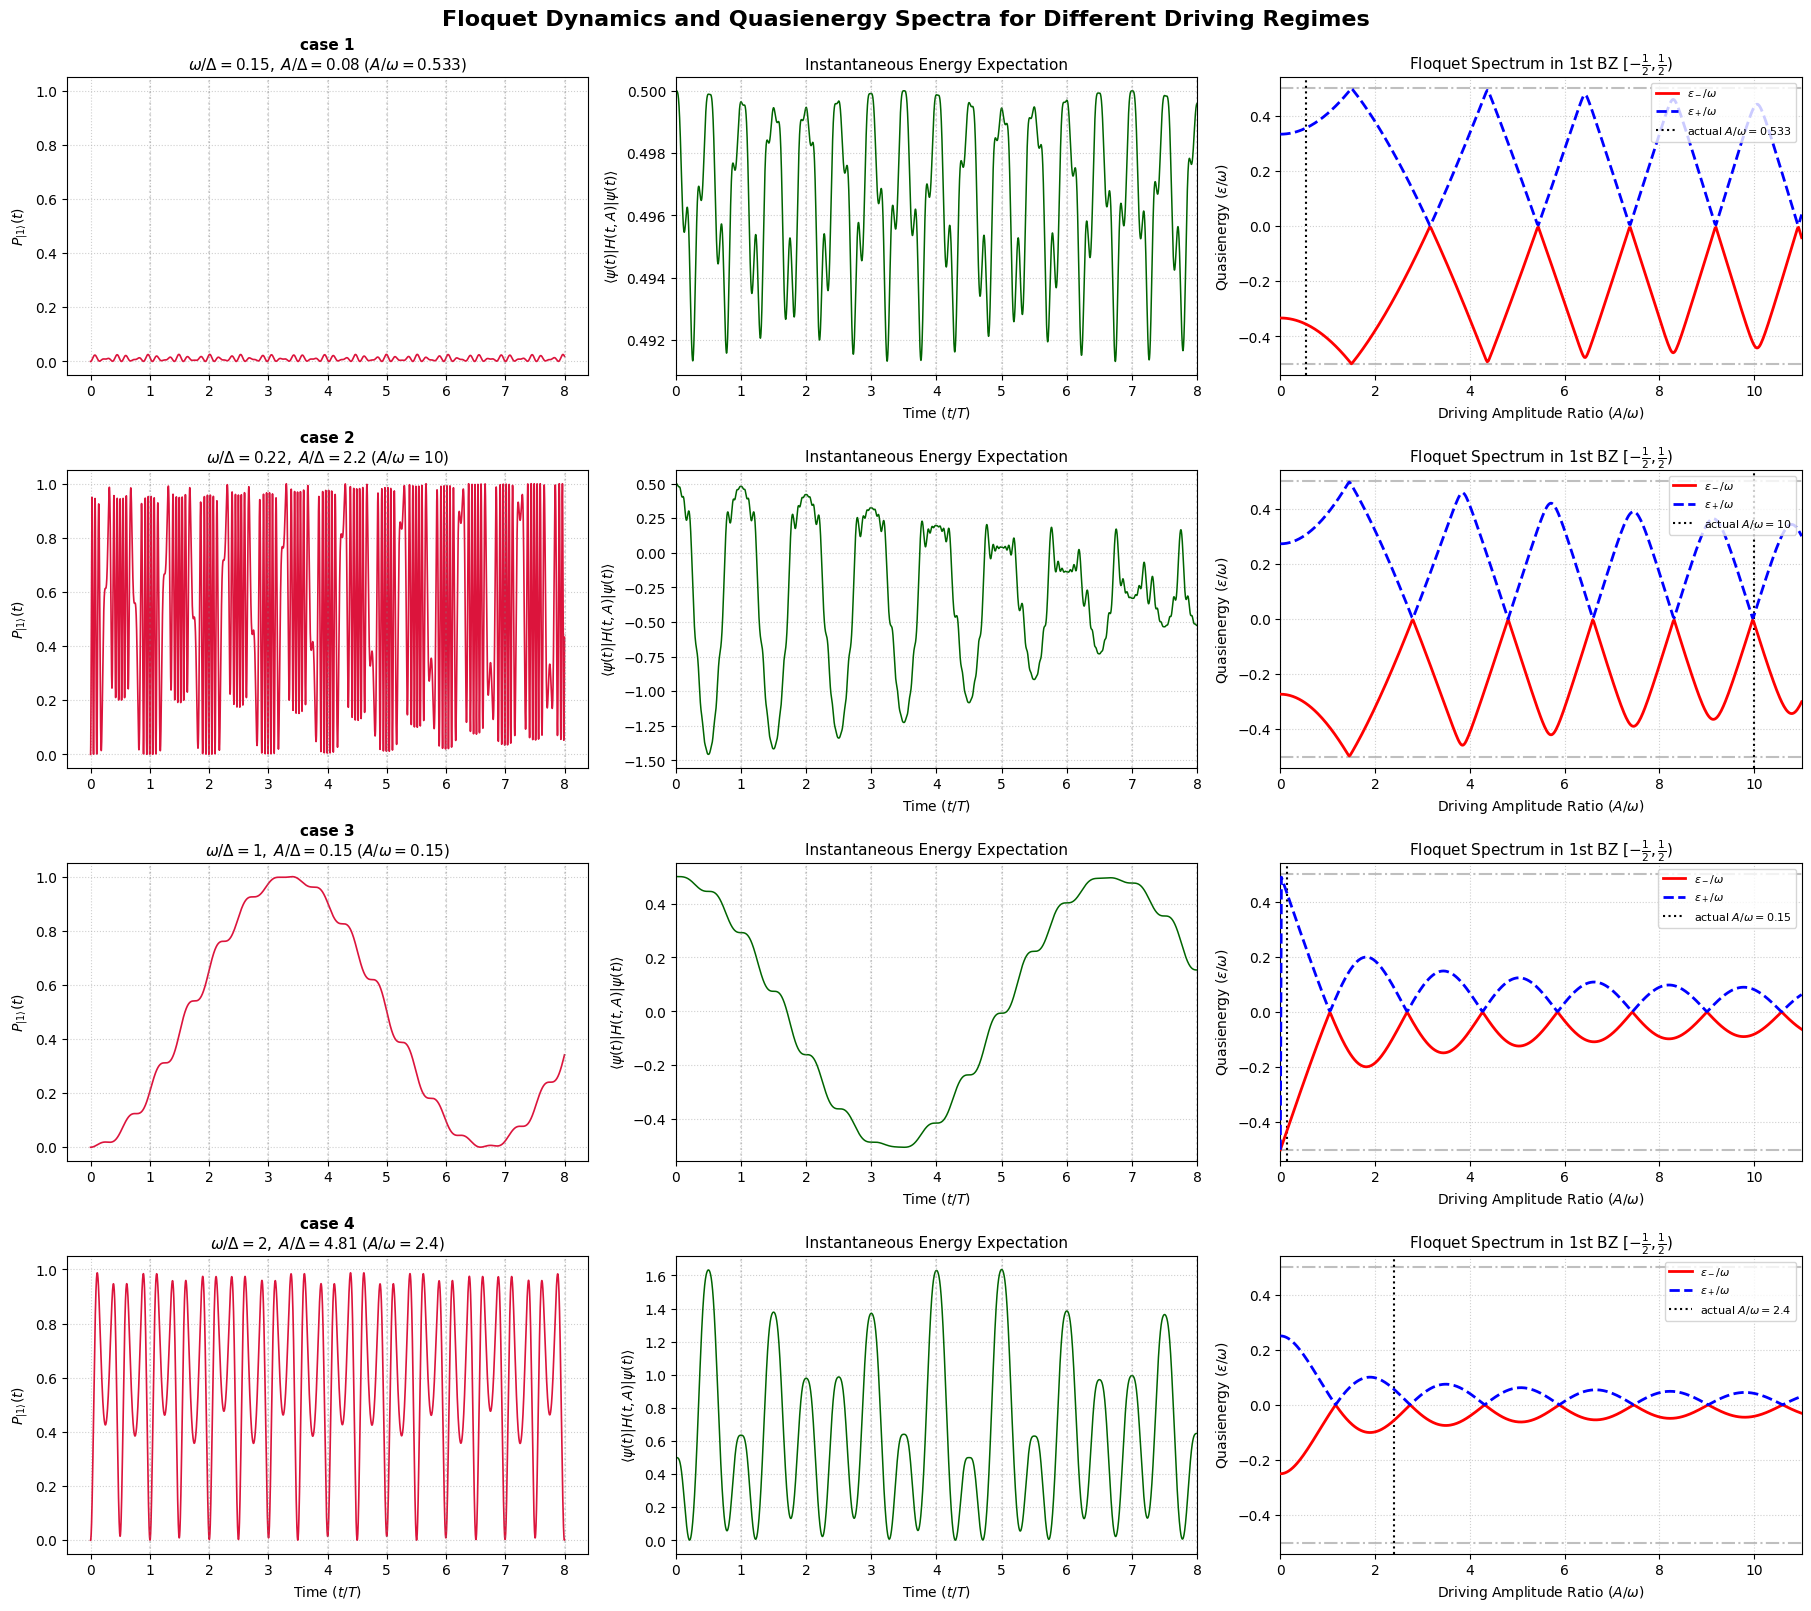

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 基础物理常量、算符与 SU(2) 传播子
# =====================================================================
Delta = 1.0

sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)


def su2_propagate(hx, hz, dt):
    h_norm = np.sqrt(hx**2 + hz**2)
    if h_norm < 1e-15:
        return np.eye(2, dtype=complex)

    cos_term = np.cos(h_norm * dt)
    sin_factor = -1j * np.sin(h_norm * dt) / h_norm
    return np.array([
        [cos_term + sin_factor * hz, sin_factor * hx],
        [sin_factor * hx, cos_term - sin_factor * hz],
    ], dtype=complex)


# =====================================================================
# 2. Floquet 代数求解器
# =====================================================================
def floquet_algebraic_solution(
    A,
    omega_value,
    delta,
    n_tau=5000,
    n_periods=8,
    points_per_period=1500,
):
    T_period = 2.0 * np.pi / omega_value
    dt = T_period / n_tau
    tau_grid = np.linspace(0.0, T_period, n_tau, endpoint=False)

    U_tau = np.zeros((n_tau, 2, 2), dtype=complex)
    U_curr = np.eye(2, dtype=complex)
    hz_const = 0.5 * delta

    for step, tau in enumerate(tau_grid):
        U_tau[step] = U_curr
        hx_mid = A * np.cos(omega_value * (tau + 0.5 * dt))
        U_curr = su2_propagate(hx_mid, hz_const, dt) @ U_curr

    eigenvals, eigenvecs = np.linalg.eig(U_curr)
    eps_alpha = -np.angle(eigenvals) / T_period
    eps_alpha = (eps_alpha + omega_value / 2.0) % omega_value - omega_value / 2.0

    u0_alpha = [eigenvecs[:, 0], eigenvecs[:, 1]]
    psi0 = np.array([1.0, 0.0], dtype=complex)
    c_alpha = [np.vdot(state, psi0) for state in u0_alpha]

    u_modes = np.zeros((2, n_tau, 2), dtype=complex)
    for alpha in range(2):
        phase_factor = np.exp(1j * eps_alpha[alpha] * tau_grid)[:, None]
        propagated_mode = np.einsum('ijk,k->ij', U_tau, u0_alpha[alpha])
        u_modes[alpha] = phase_factor * propagated_mode

    sample_sub_indices = np.linspace(
        0, n_tau, points_per_period, endpoint=False, dtype=int
    )
    tau_sample = tau_grid[sample_sub_indices]
    period_offsets = np.arange(n_periods) * T_period
    t_eval = (period_offsets[:, None] + tau_sample[None, :]).ravel()
    tau_indices = np.tile(sample_sub_indices, n_periods)

    psi_t = (
        c_alpha[0] * np.exp(-1j * eps_alpha[0] * t_eval)[:, None]
        * u_modes[0, tau_indices]
        + c_alpha[1] * np.exp(-1j * eps_alpha[1] * t_eval)[:, None]
        * u_modes[1, tau_indices]
    )

    P1 = np.abs(psi_t[:, 1])**2

    # 完整哈密顿量 H(t,A) = delta/2 sigma_z + A cos(omega t) sigma_x
    tau_eval = np.tile(tau_sample, n_periods)
    H_t = (
        0.5 * delta * sigma_z[None, :, :]
        + A * np.cos(omega_value * tau_eval)[:, None, None]
        * sigma_x[None, :, :]
    )
    energy_values = np.real(
        np.einsum('bi,bij,bj->b', psi_t.conj(), H_t, psi_t)
    )

    return t_eval, P1, energy_values, np.sort(eps_alpha)


# =====================================================================
# 3. Floquet 准能量扫描：每个点显式排序 lower / upper branch
# =====================================================================
def quasienergy_sweep(omega_value, delta, amplitude_ratios, n_tau=1000):
    """
    amplitude_ratios = A / omega.
    返回的两列始终满足 spectrum[:, 0] <= spectrum[:, 1]。
    不使用本征矢重叠追踪，也不插入 NaN。
    """
    spectrum = np.empty((len(amplitude_ratios), 2), dtype=float)
    T_period = 2.0 * np.pi / omega_value
    dt = T_period / n_tau
    hz_const = 0.5 * delta

    for idx, ratio in enumerate(amplitude_ratios):
        amplitude = ratio * omega_value
        U_period = np.eye(2, dtype=complex)

        for step in range(n_tau):
            time_mid = (step + 0.5) * dt
            hx_mid = amplitude * np.cos(omega_value * time_mid)
            U_period = su2_propagate(hx_mid, hz_const, dt) @ U_period

        eigenvalues = np.linalg.eigvals(U_period)
        epsilon = -np.angle(eigenvalues) / T_period
        epsilon = (epsilon + omega_value / 2.0) % omega_value - omega_value / 2.0
        spectrum[idx] = np.sort(epsilon)

    return spectrum


# =====================================================================
# 4. 四个物理 regime 与绘图
# =====================================================================
regimes = [
    ('case 1', 0.15 * Delta, 0.08 * Delta),
    ('case 2', 0.22 * Delta, 2.20 * Delta),
    ('case 3', 1.00 * Delta, 0.15 * Delta),
    ('case 4', 2.00 * Delta, 2.4048 * (2.00 * Delta)),
]

actual_amplitude_ratios = np.array([
    amplitude / omega_value
    for _, omega_value, amplitude in regimes
])
amplitude_ratio_max = max(3.0, 1.1 * actual_amplitude_ratios.max())
amplitude_ratios = np.linspace(0.0, amplitude_ratio_max, 500)

fig, axes = plt.subplots(4, 3, figsize=(18, 16), constrained_layout=True)

for row, (label, regime_omega, regime_A) in enumerate(regimes):
    period = 2.0 * np.pi / regime_omega
    actual_amplitude_ratio = regime_A / regime_omega

    t_values, p1_values, energy_values, _ = floquet_algebraic_solution(
        A=regime_A,
        omega_value=regime_omega,
        delta=Delta,
        n_tau=3000,
        n_periods=8,
        points_per_period=1000,
    )
    time_in_periods = t_values / period
    spectrum = quasienergy_sweep(
        omega_value=regime_omega,
        delta=Delta,
        amplitude_ratios=amplitude_ratios,
        n_tau=1000,
    )

    ax_p1, ax_energy, ax_spectrum = axes[row]

    # Column 1: excited-state probability
    ax_p1.plot(time_in_periods, p1_values, color='crimson', lw=1.2)
    ax_p1.set_ylim(-0.05, 1.05)
    ax_p1.set_ylabel(r'$P_{|1\rangle}(t)$')
    ax_p1.set_title(
        f'{label}\n'
        + rf'$\omega/\Delta={regime_omega / Delta:.3g},\; '
        rf'A/\Delta={regime_A / Delta:.3g}\;'
        rf'(A/\omega={actual_amplitude_ratio:.3g})$',
        fontsize=11,
        fontweight='bold',
    )
    ax_p1.grid(True, linestyle=':', alpha=0.6)

    # Column 2: <psi(t)|H(t,A)|psi(t)>
    ax_energy.plot(
        time_in_periods,
        energy_values,
        color='darkgreen',
        lw=1.1,
        label=r'$\langle\psi(t)|H(t,A)|\psi(t)\rangle$',
    )
    ax_energy.set_xlabel(r'Time ($t/T$)')
    ax_energy.set_ylabel(r'$\langle\psi(t)|H(t,A)|\psi(t)\rangle$')
    ax_energy.set_title('Instantaneous Energy Expectation', fontsize=11)
    ax_energy.set_xlim(0, 8)
    ax_energy.set_xticks(np.arange(0, 9, 1))
    ax_energy.grid(True, linestyle=':', alpha=0.6)

    # Column 3: explicitly sorted lower and upper quasienergy branches
    ax_spectrum.plot(
        amplitude_ratios,
        spectrum[:, 0] / regime_omega,
        color='red',
        lw=2.0,
        label=r'$\epsilon_-/\omega$',
        zorder=3,
    )
    ax_spectrum.plot(
        amplitude_ratios,
        spectrum[:, 1] / regime_omega,
        color='blue',
        lw=2.0,
        linestyle='--',
        label=r'$\epsilon_+/\omega$',
        zorder=3,
    )

    ax_spectrum.axvline(
        actual_amplitude_ratio,
        color='black',
        linestyle=':',
        lw=1.5,
        label=rf'actual $A/\omega={actual_amplitude_ratio:.3g}$',
        zorder=2,
    )
    ax_spectrum.axhline(0.5, color='gray', linestyle='-.', alpha=0.5, zorder=1)
    ax_spectrum.axhline(-0.5, color='gray', linestyle='-.', alpha=0.5, zorder=1)
    ax_spectrum.set_xlabel(r'Driving Amplitude Ratio ($A/\omega$)')
    ax_spectrum.set_ylabel(r'Quasienergy ($\epsilon/\omega$)')
    ax_spectrum.set_xlim(0, amplitude_ratio_max)
    ax_spectrum.set_ylim(-0.54, 0.54)
    ax_spectrum.set_title(
        r'Floquet Spectrum in 1st BZ $[-\frac{1}{2},\frac{1}{2})$',
        fontsize=11,
    )
    ax_spectrum.grid(True, linestyle=':', alpha=0.6)
    ax_spectrum.legend(fontsize=8, loc='upper right')

    # Mark each integer-period boundary in both time-domain plots.
    for axis in (ax_p1, ax_energy):
        for period_index in range(1, 9):
            axis.axvline(
                period_index,
                color='gray',
                linestyle=':',
                alpha=0.3,
            )

    if row == len(regimes) - 1:
        ax_p1.set_xlabel(r'Time ($t/T$)')

fig.suptitle(
    'Floquet Dynamics and Quasienergy Spectra for Different Driving Regimes',
    fontsize=16,
    fontweight='bold',
)
plt.show()


/tmp/ipykernel_2304/3480927184.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper right', fontsize=8)


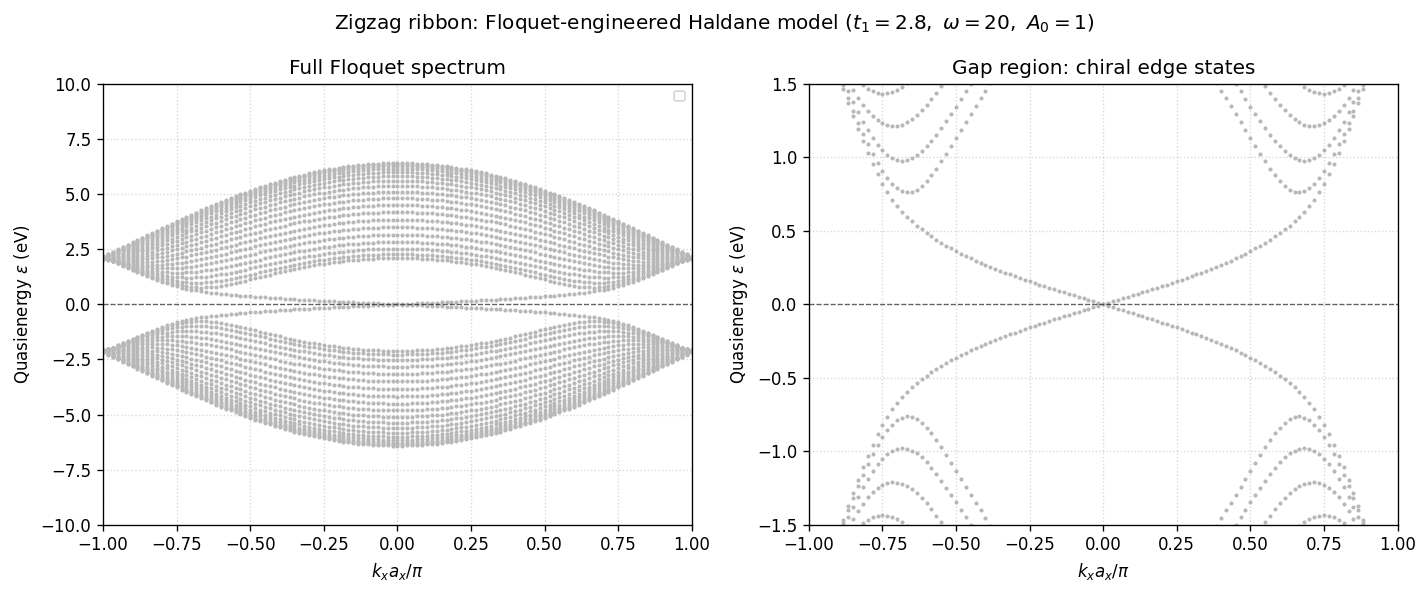

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
#  Zigzag-ribbon Floquet spectrum: graphene under circularly-polarised light
#  (the Floquet-engineered Haldane model).  Parameters are taken from the bulk
#  Floquet-Haldane cell (t1 = 2.8, omega = 20, A0 = 1) so the two cells agree.
#  The helical drive  A(t) = A0 (cos wt, sin wt)  opens a chiral (Haldane) gap
#  at the Dirac points K, K'; a zigzag ribbon therefore carries two counter-
#  propagating chiral edge modes that cross the gap, one on each edge.
# =============================================================================

# ----------------------------- parameters (match cell 5) --------------------
t1 = 2.8                 # nearest-neighbour hopping (eV)          [graphene]
a  = 1.0                 # carbon-carbon bond length  a_cc
omega = 20.0             # drive frequency (eV), off-resonant (> 6 t1)
A0 = 1.0                 # dimensionless drive amplitude  e A0 a / hbar
T = 2.0*np.pi/omega      # drive period
N_t = 200                # time steps per period (converged U(T))
N_cells = 20             # number of zigzag columns across the ribbon width
N_k = 121                # number of k_x points along the ribbon

a_x = np.sqrt(3.0)*a     # lattice constant along the ribbon (x) direction
N = 2*N_cells            # total number of sites (one A + one B per column)

# ------------------- zigzag ribbon geometry (explicit site positions) -------
#  Column j holds an A site and a B site stacked along y; the zigzag edges are
#  the A site of column 0 (bottom) and the B site of the last column (top).
pos = []
for j in range(N):
    subl = j % 2                       # 0 = A, 1 = B
    xoff = (j//2 % 2) * (a_x/2.0)      # alternating x offset -> zigzag edges
    y = (j//2) * (3.0*a/2.0) + (j%2)*a
    pos.append((xoff, y, subl))
pos = np.array(pos)

# ------- all nearest-neighbour A->B bonds (i_A, j_B, dx, dy), with the -------
# ------- periodic images along x so boundary bonds are not missed      -------
bonds = []
for i in range(N):
    if pos[i, 2] != 0:                 # bonds start on the A sublattice
        continue
    for j in range(N):
        if pos[j, 2] != 1:             # and end on the B sublattice
            continue
        dij = pos[j, :2] - pos[i, :2]
        for nx in (-1, 0, 1):          # nearest-neighbour images along x
            d = dij + np.array([nx*a_x, 0.0])
            if abs(np.linalg.norm(d) - a) < 1e-6:
                bonds.append((i, j, d[0], d[1]))

edge_idx = [0, N-1]                    # bottom edge = site 0, top edge = site N-1

# ------------------- time-dependent ribbon Hamiltonian ----------------------
def build_H(kx, t):
    """Ribbon Hamiltonian with the Peierls substitution  k -> k + A(t)."""
    H = np.zeros((N, N), dtype=complex)
    Ax = A0*np.cos(omega*t)
    Ay = A0*np.sin(omega*t)
    for (i, j, dx, dy) in bonds:
        phase = kx*dx + Ax*dx + Ay*dy          # (k + A(t)) . d
        H[i, j] += -t1*np.exp(-1j*phase)       # A -> B   (matches cell 5 sign)
        H[j, i] += -t1*np.exp(+1j*phase)       # B -> A
    return H

# ---------------- single-period Floquet operator  U(T) ----------------------
def floquet_spectrum(kx):
    """Return sorted quasienergies and per-state edge weights at momentum kx."""
    dt = T/N_t
    U = np.eye(N, dtype=complex)
    for n in range(N_t):                       # U(T) = prod exp(-i H(t_n) dt)
        Ht = build_H(kx, (n + 0.5)*dt)
        w, v = np.linalg.eigh(Ht)              # exact small-step exponential
        U = (v @ np.diag(np.exp(-1j*w*dt)) @ v.conj().T) @ U
    evals, evecs = np.linalg.eig(U)
    eps = -np.angle(evals)/T                   # quasienergy
    eps = (eps + omega/2.0) % omega - omega/2.0   # fold into [-omega/2, omega/2]
    order = np.argsort(eps)
    eps = eps[order]; evecs = evecs[:, order]
    w_bottom = np.abs(evecs[edge_idx[0]])**2   # weight on the bottom edge
    w_top    = np.abs(evecs[edge_idx[1]])**2   # weight on the top edge
    return eps, np.maximum(w_bottom, w_top)

# ------------------------------- spectrum sweep -----------------------------
k_vals = np.linspace(-np.pi/a_x, np.pi/a_x, N_k)
quasi, edge_w = [], []
for kx in k_vals:
    eps, w = floquet_spectrum(kx)
    quasi.append(eps); edge_w.append(w)
quasi = np.array(quasi); edge_w = np.array(edge_w)

# -------------------------------- plotting ---------------------------------
kx_norm = k_vals * a_x / np.pi
edge_threshold = 0.15     # states localised on one edge -> chiral edge mode
 
KK = np.tile(kx_norm[:, None], (1, N))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)
for ax, ymax in zip(axes, [omega/2.0, 1.5]):
    ax.scatter(KK , quasi , color='0.72', s=6, linewidths=0)
     
    ax.axhline(0, color='black', linestyle='--', lw=0.8, alpha=0.6)
    ax.set_xlim(-1, 1); ax.set_ylim(-ymax, ymax)
    ax.set_xlabel(r'$k_x a_x / \pi$')
    ax.set_ylabel(r'Quasienergy $\varepsilon$ (eV)')
    ax.grid(True, linestyle=':', alpha=0.5)
axes[0].set_title('Full Floquet spectrum')
axes[1].set_title('Gap region: chiral edge states')
axes[0].legend(loc='upper right', fontsize=8)
fig.suptitle(r'Zigzag ribbon: Floquet-engineered Haldane model '
             r'($t_1=2.8,\ \omega=20,\ A_0=1$)', fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2304/2239307023.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=11, frameon=True)


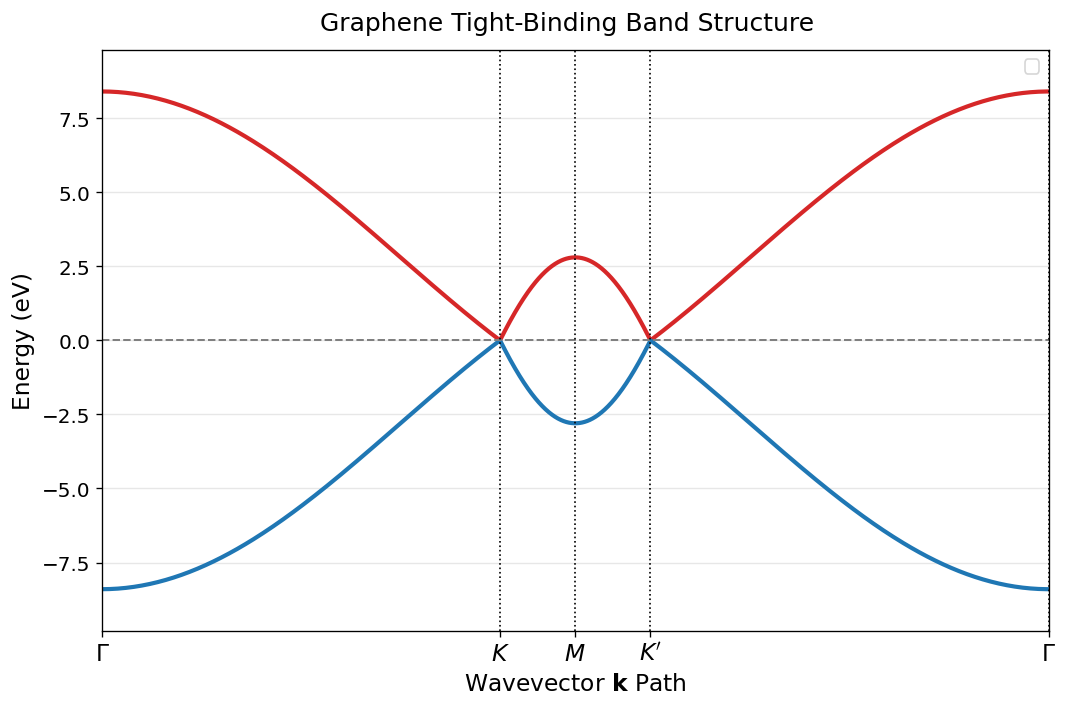

In [4]:
import numpy as np
import matplotlib.pyplot as plt

 
epsilon = 0.0     
t = 2.8           
n_pts = 200       

 
points = {
    r'$\Gamma$': np.array([0.0, 0.0]),
    r'$K$': np.array([1.0 / 3.0, 2.0 / 3.0]),
    r'$M$': np.array([0.5, 0.5]),
    r"$K'$": np.array([2.0 / 3.0, 1.0 / 3.0]),
}

path_labels = [r'$\Gamma$', r'$K$', r'$M$', r"$K'$", r'$\Gamma$']
path_points = [points[label] for label in path_labels[:-1]] + [points[r'$\Gamma$']]

 
def get_cartesian_dist(k_start, k_end):
    dk = k_end - k_start
    return np.sqrt(dk[0]**2 + dk[1]**2 +  dk[0] * dk[1])

k_vecs = []
k_dist = []
node_indices = [0]
total_dist = 0.0

for i in range(len(path_points) - 1):
    k_start = path_points[i]
    k_end = path_points[i + 1]
    seg_dist = get_cartesian_dist(k_start, k_end)
    alpha_values = np.linspace(0.0, 1.0, n_pts, endpoint=False)
    segment_points = (1.0 - alpha_values[:, None]) * k_start + alpha_values[:, None] * k_end
    k_vecs.extend(segment_points)
    k_dist.extend(total_dist + seg_dist * alpha_values)
    total_dist += seg_dist
    node_indices.append(len(k_vecs))

 
k_vecs.append(path_points[-1])
k_dist.append(total_dist)
k_vecs = np.array(k_vecs)
k_dist = np.array(k_dist)

assert len(k_vecs) == len(k_dist)
assert node_indices[-1] == len(k_vecs) - 1

 
bands_val = []
bands_con = []

for k1, k2 in k_vecs:
    f_k = 1.0 + np.exp(-1j * 2 * np.pi * k1) + np.exp(-1j * 2 * np.pi * k2)
    bands_con.append(epsilon + t * np.abs(f_k))
    bands_val.append(epsilon - t * np.abs(f_k))

bands_con = np.array(bands_con)
bands_val = np.array(bands_val)

 
plt.figure(figsize=(9, 6), dpi=120)
plt.plot(k_dist, bands_con, color='#d62728', linewidth=2.5 )
plt.plot(k_dist, bands_val, color='#1f77b4', linewidth=2.5 )
plt.axhline(0, color='gray', linestyle='--', linewidth=1.2 )

node_positions = k_dist[node_indices]
for pos in node_positions:
    plt.axvline(pos, color='black', linestyle=':', linewidth=1.0)

plt.xticks(node_positions, path_labels, fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel('Energy (eV)', fontsize=14)
plt.xlabel(r'Wavevector $\mathbf{k}$ Path', fontsize=14)
plt.title(r"Graphene Tight-Binding Band Structure  ", fontsize=15, pad=12)
plt.xlim(k_dist[0], k_dist[-1])
plt.ylim(-3.5 * t, 3.5 * t)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

Floquet-engineered Haldane model from graphene (helical light)
  t1 = 2.8 eV,  hbar*omega = 20.0 eV,  A0 = 1.0
  gap at K        = 1.2774 eV   (2|dz| = 1.1749 eV)
  dz(K) = +0.5875 eV,   dz(K') = -0.6090 eV
  opposite signs at K and K' : True
  Chern number of the lower Floquet band :  C = +1.0000


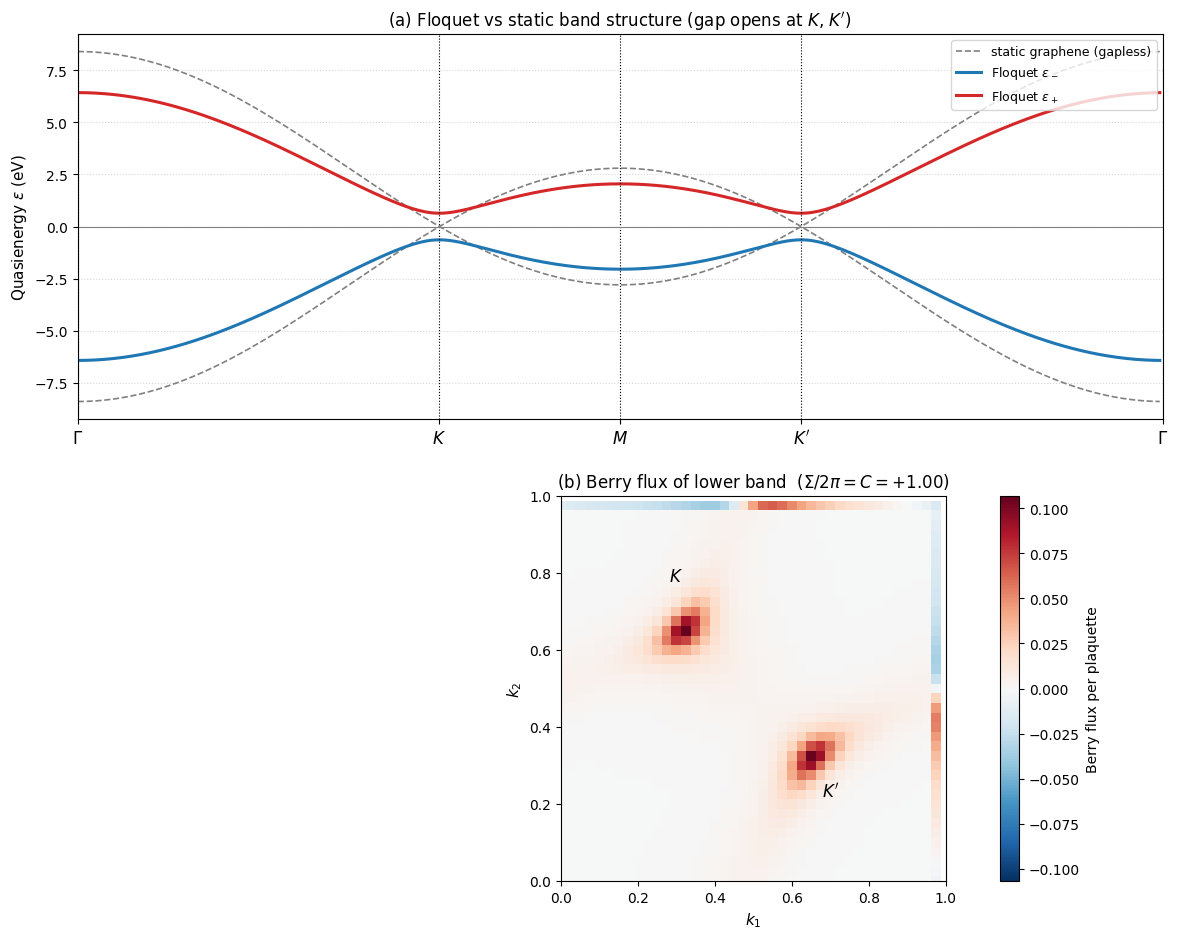

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
#  Floquet engineering of the HALDANE model from graphene under helical light
# =============================================================================
#  Bare graphene (nearest-neighbour hopping t1) is driven by a circularly
#  polarised field  A(t) = A0 (cos wt, sin wt)  (one helicity).  The single-
#  period Floquet operator  U(T) = T exp[-i int_0^T H(t) dt]  is built by exact
#  stroboscopic integration, and the effective Floquet Hamiltonian is
#       H_F(k) = (i/T) ln U(T)  =  d0 I + dx sx + dy sy + dz sz .
#  The drive generates a complex NEXT-NEAREST-NEIGHBOUR hopping -- a Haldane
#  mass term  dz(k)  -- that opens a gap of OPPOSITE sign at the two Dirac
#  points K and K'.  The lower quasienergy band therefore carries a Chern
#  number  C = +1  (the opposite helicity A0(cos,-sin) gives C = -1).

# ----------------------------- parameters -----------------------------------
t1 = 2.8                 # nearest-neighbour hopping (eV)          [graphene]
omega = 20.0             # drive frequency (eV); off-resonant (> bandwidth 6 t1)
A0 = 1.0                 # dimensionless drive amplitude  e A0 a / hbar
T = 2.0*np.pi/omega
N_t = 200                # time steps per period (converged U(T))

# Pauli matrices in the sublattice basis {A, B}
sx = np.array([[0., 1.], [1., 0.]], complex)
sy = np.array([[0., -1j], [1j, 0.]], complex)
sz = np.array([[1., 0.], [0., -1.]], complex)

# -------- real-space geometry (bond length a_cc = 1) ------------------------
d1 = np.array([0.0, 1.0])                        # 3 NN bond vectors  A -> B
d2 = np.array([np.sqrt(3.0)/2.0, -0.5])
d3 = np.array([-np.sqrt(3.0)/2.0, -0.5])
NN = np.array([d1, d2, d3])

# reciprocal lattice vectors (a_i . b_j = 2 pi delta_ij, with a1=d1-d3, a2=d1-d2)
b1 = 2*np.pi*np.array([ 1.0/np.sqrt(3.0), 1.0/3.0])
b2 = 2*np.pi*np.array([-1.0/np.sqrt(3.0), 1.0/3.0])

# --------------------- time-dependent Hamiltonian ---------------------------
def H_k_t(kx, ky, t):
    """H(k,t) = -t1 * sum_j [ e^{+i(k + A(t)).d_j} |B><A| + h.c. ]"""
    kdot = kx*NN[:, 0] + ky*NN[:, 1]
    Ax = A0*np.cos(omega*t)
    Ay = A0*np.sin(omega*t)
    Adot = Ax*NN[:, 0] + Ay*NN[:, 1]
    f = np.sum(np.exp(1j*(kdot + Adot)))
    return np.array([[0.0, -t1*np.conj(f)],
                     [-t1*f, 0.0]], complex)

def floquet_hamiltonian(kx, ky, N_steps=N_t):
    """Return (H_F, sorted quasienergies, eigenvectors) from U(T)."""
    U = np.eye(2, dtype=complex)
    dt = T/N_steps
    for n in range(N_steps):
        Ht = H_k_t(kx, ky, (n + 0.5)*dt)
        w, v = np.linalg.eigh(Ht)
        U = (v @ np.diag(np.exp(-1j*w*dt)) @ v.conj().T) @ U
    evals, evecs = np.linalg.eig(U)
    eps = -np.angle(evals)/T
    eps = (eps + omega/2.0) % omega - omega/2.0          # fold into [-w/2, w/2]
    order = np.argsort(eps)
    eps = eps[order]
    evecs = evecs[:, order]
    H_F = (evecs * eps) @ evecs.conj().T
    return H_F, eps, evecs

def dz_of(H_F):
    """Haldane mass = (1/2) Tr[ sz . H_F ]."""
    return 0.5*np.real(np.trace(sz @ H_F))

# --------------------- high-symmetry path (Cartesian k) ---------------------
Gamma = np.array([0.0, 0.0])
K     = np.array([4.0*np.pi/(3.0*np.sqrt(3.0)), 0.0])
M     = np.array([np.pi/np.sqrt(3.0), np.pi/3.0])
Kp    = np.array([2.0*np.pi/(3.0*np.sqrt(3.0)), 2.0*np.pi/3.0])
path_pts    = [Gamma, K, M, Kp, Gamma]
node_labels = [r'$\Gamma$', r'$K$', r'$M$', r"$K'$", r'$\Gamma$']

n_seg = 120
segs_k, segs_s, node_pos = [], [], []
s_total = 0.0
for i in range(len(path_pts) - 1):
    start, end = path_pts[i], path_pts[i + 1]
    alpha = np.linspace(0.0, 1.0, n_seg, endpoint=False)
    segs_k.append(start[None, :] + alpha[:, None]*(end - start)[None, :])
    segs_s.append(s_total + alpha*np.linalg.norm(end - start))
    node_pos.append(s_total)
    s_total += np.linalg.norm(end - start)
node_pos.append(s_total)
k_path = np.concatenate(segs_k, axis=0)
s_path = np.concatenate(segs_s)
node_pos = np.array(node_pos)

# ------------------- band structure along the path --------------------------
eps_bands    = np.zeros((len(k_path), 2))
static_bands = np.zeros((len(k_path), 2))
dz_path      = np.zeros(len(k_path))
for i in range(len(k_path)):
    kx, ky = k_path[i]
    H_F, eps, _ = floquet_hamiltonian(kx, ky)
    eps_bands[i] = eps
    dz_path[i] = dz_of(H_F)
    f = np.sum(np.exp(1j*(kx*NN[:, 0] + ky*NN[:, 1])))
    static_bands[i] = [t1*abs(f), -t1*abs(f)]

# ----------------------- zoom through the K point ---------------------------
qmax = 0.35
q = np.linspace(-qmax, qmax, 160)
eps_zoom    = np.zeros((len(q), 2))
static_zoom = np.zeros((len(q), 2))
for i, qq in enumerate(q):
    kx = K[0] + qq
    H_F, eps, _ = floquet_hamiltonian(kx, 0.0)
    eps_zoom[i] = eps
    f = np.sum(np.exp(1j*(kx*NN[:, 0])))
    static_zoom[i] = [t1*abs(f), -t1*abs(f)]

# --------------------- gap & Haldane mass at K, K' --------------------------
H_F_K, eps_K, _   = floquet_hamiltonian(K[0], K[1])
H_F_Kp, eps_Kp, _ = floquet_hamiltonian(Kp[0], Kp[1])
dz_K  = dz_of(H_F_K)
dz_Kp = dz_of(H_F_Kp)
gap_K = eps_K[1] - eps_K[0]

# ---------------------- Chern number (Fukui-Hatsugai-Suzuki) ----------------
def chern_number(Nk=40):
    ks = np.linspace(0.0, 1.0, Nk, endpoint=False)
    psi = np.zeros((Nk, Nk, 2), complex)
    for i in range(Nk):
        for j in range(Nk):
            kx = ks[i]*b1[0] + ks[j]*b2[0]
            ky = ks[i]*b1[1] + ks[j]*b2[1]
            _, eps, evecs = floquet_hamiltonian(kx, ky, N_steps=100)
            psi[i, j] = evecs[:, 0]                      # lower quasienergy band
    flux = np.zeros((Nk, Nk))
    for i in range(Nk):
        for j in range(Nk):
            ip, jp = (i + 1) % Nk, (j + 1) % Nk
            L1 = np.vdot(psi[i, j], psi[ip, j]);     L1 /= abs(L1)
            L2 = np.vdot(psi[ip, j], psi[ip, jp]);   L2 /= abs(L2)
            L3 = np.vdot(psi[ip, jp], psi[i, jp]);   L3 /= abs(L3)
            L4 = np.vdot(psi[i, jp], psi[i, j]);     L4 /= abs(L4)
            flux[i, j] = np.angle(L1*L2*L3*L4)
    C = flux.sum()/(2.0*np.pi)
    return C, flux, ks

C, flux, ks = chern_number(Nk=40)

# ================================ report ====================================
print("=" * 66)
print("Floquet-engineered Haldane model from graphene (helical light)")
print(f"  t1 = {t1} eV,  hbar*omega = {omega} eV,  A0 = {A0}")
print(f"  gap at K        = {gap_K:.4f} eV   (2|dz| = {2*abs(dz_K):.4f} eV)")
print(f"  dz(K) = {dz_K:+.4f} eV,   dz(K') = {dz_Kp:+.4f} eV")
print(f"  opposite signs at K and K' : {np.sign(dz_K) != np.sign(dz_Kp)}")
print(f"  Chern number of the lower Floquet band :  C = {C:+.4f}")
print("=" * 66)

# ================================ plotting ==================================
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# ---- (a) Floquet quasienergy bands vs static graphene ---------------------
ax = axes[0]
ax.plot(s_path, static_bands[:, 0], '--', color='gray', lw=1.2,
        label='static graphene (gapless)')
ax.plot(s_path, static_bands[:, 1], '--', color='gray', lw=1.2)
ax.plot(s_path, eps_bands[:, 0], color='#1f77b4', lw=2.2,
        label=r'Floquet $\epsilon_-$')
ax.plot(s_path, eps_bands[:, 1], color='#d62728', lw=2.2,
        label=r'Floquet $\epsilon_+$')
for pos in node_pos:
    ax.axvline(pos, color='black', ls=':', lw=0.8)
ax.axhline(0, color='gray', lw=0.8)
ax.set_xticks(node_pos)
ax.set_xticklabels(node_labels, fontsize=12)
ax.set_xlim(node_pos[0], node_pos[-1])
ax.set_ylabel(r'Quasienergy $\epsilon$ (eV)', fontsize=11)
ax.set_title('(a) Floquet vs static band structure (gap opens at $K$, $K\'$)',
             fontsize=12)
ax.grid(True, ls=':', alpha=0.5)
ax.legend(loc='upper right', fontsize=9)

# ---- (b) Berry curvature of the lower Floquet band ------------------------
ax = axes[1]
vmax = np.abs(flux).max()
pc = ax.pcolormesh(ks, ks, flux.T, cmap='RdBu_r', shading='auto',
                   vmin=-vmax, vmax=vmax)
 
ax.annotate(r'$K$', (1/3, 2/3), xytext=(0.30, 0.78), fontsize=12,
            ha='center', color='black')
ax.annotate(r"$K'$", (2/3, 1/3), xytext=(0.70, 0.22), fontsize=12,
            ha='center', color='black')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_xlabel(r'$k_1$', fontsize=11)
ax.set_ylabel(r'$k_2$', fontsize=11)
ax.set_title(rf'(b) Berry flux of lower band  ($\Sigma/2\pi = C = {C:+.2f}$)',
             fontsize=12)
cb = fig.colorbar(pc, ax=ax)
cb.set_label(r'Berry flux per plaquette', fontsize=10)
 
 
 